# Fase 4 — Integración LLM: Explicaciones en Lenguaje Natural
## Proyecto Final IA · EAFIT 2026-1

**Objetivo:** Usar un LLM (LLaMA-3 vía Groq API, **gratuito**) para convertir la predicción
del modelo CNN + la descripción de zonas activas del Grad-CAM en una explicación agronómica
en lenguaje natural, dirigida a agricultores o técnicos de campo.

**Responsable principal:** Integrante 2 (P2) — diseño de prompts, integración API  
**Apoyo:** Integrante 1 (P1) — evaluación cualitativa, ejemplos para el informe

**Prerequisito:** `fase3_gradcam.ipynb` completado.  
Drive debe tener `artifacts/gradcam_results.json` y `artifacts/config_modelo.json`.

---
> **API usada:** Groq Cloud — https://console.groq.com  
> **Modelo:** `llama-3.1-8b-instant` (gratuito, ~600 tokens/s)  
> **Costo:** $0 — el tier gratuito de Groq cubre ampliamente este proyecto


## 0. Setup — Drive, dependencias y API Key

In [1]:
!pip install -q groq Pillow matplotlib
print('✅ Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.4 MB/s eta 0:00:00
✅ Dependencias instaladas


In [17]:
from google.colab import drive
from pathlib import Path
import shutil, json, os

drive.mount('/content/drive')

DRIVE_DIR       = Path('/content/drive/MyDrive/IA_EAFIT')
DRIVE_ARTIFACTS = DRIVE_DIR / 'artifacts'
DRIVE_FIGURES   = DRIVE_DIR / 'figures'
ARTIFACTS       = Path('/content/artifacts')
ARTIFACTS.mkdir(exist_ok=True)

def save_to_drive(local_path, subfolder='artifacts', verbose=True):
    local_path = Path(local_path)
    if not local_path.exists():
        if verbose: print(f'  ⚠️  No encontrado: {local_path}')
        return None
    dest = DRIVE_DIR / subfolder / local_path.name
    (DRIVE_DIR / subfolder).mkdir(exist_ok=True)
    shutil.copy2(local_path, dest)
    if verbose:
        print(f'  ✅ {local_path.name:40s} → Drive/{subfolder}/ ({dest.stat().st_size/1024:.1f} KB)')
    return dest

def load_from_drive(filename, subfolder='artifacts', dest_dir='/content/artifacts'):
    src = DRIVE_DIR / subfolder / filename
    if not src.exists():
        print(f'  ⚠️  No encontrado en Drive: {src}')
        return None
    dest = Path(dest_dir); dest.mkdir(parents=True, exist_ok=True)
    dest_file = dest / filename
    shutil.copy2(src, dest_file)
    print(f'  ✅ {filename} ← Drive/{subfolder}/')
    return dest_file

def copy_dir_contents(src_dir, dest_dir, verbose=True):
    """Copies the *contents* of src_dir directly into dest_dir."""
    src_dir = Path(src_dir)
    dest_dir = Path(dest_dir)

    if not src_dir.exists() or not src_dir.is_dir():
        if verbose: print(f'  ⚠️  Directorio origen no encontrado: {src_dir}')
        return

    if dest_dir.exists():
        shutil.rmtree(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    for item in src_dir.iterdir():
        item_dest = dest_dir / item.name
        if item.is_dir():
            shutil.copytree(item, item_dest)
        else: # is_file or other
            shutil.copy2(item, item_dest)
    if verbose: print(f'  ✅ Contenido de {src_dir.name}/ copiado a {dest_dir.name}/')


print('Restaurando artefactos desde Drive...')
load_from_drive('gradcam_results.json', 'artifacts')
load_from_drive('config_modelo.json',   'artifacts')

# --- Cargar directorios de imágenes desde las rutas específicas del usuario ---
print('Cargando directorios de imágenes desde Drive (rutas específicas)...')

# Cargar 'dataset' de Drive a '/content/dataset_split'
# El usuario indicó que el dataset está en DRIVE_DIR / 'dataset'
copy_dir_contents(DRIVE_DIR / 'dataset', Path('/content/dataset_split'))

# Cargar 'gradcam_imgs' desde 'DRIVE_DIR / artifacts' a '/content/gradcam_imgs'
# El usuario indicó que las imágenes gradcam están en DRIVE_DIR / 'artifacts'
copy_dir_contents(DRIVE_DIR / 'artifacts', Path('/content/gradcam_imgs'))

print('\n✅ Drive montado y artefactos restaurados')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restaurando artefactos desde Drive...
  ✅ gradcam_results.json ← Drive/artifacts/
  ✅ config_modelo.json ← Drive/artifacts/
Cargando directorios de imágenes desde Drive (rutas específicas)...
  ✅ Contenido de dataset/ copiado a dataset_split/
  ✅ Contenido de artifacts/ copiado a gradcam_imgs/

✅ Drive montado y artefactos restaurados


In [18]:
import os
from google.colab import userdata

# ── Opción A: desde Colab Secrets (recomendado) ────────────────────────────
# En Colab: icono de llave (🔑) en el panel izquierdo → Add secret
# Nombre: GROQ_API_KEY  Valor: gsk_xxxxxxxx
try:
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    print('✅ API key cargada desde Colab Secrets')
except Exception:
    # ── Opción B: pegar directamente (menos seguro) ────────────────────────
    GROQ_API_KEY = 'gsk_PEGA_TU_API_KEY_AQUI'
    print('⚠️  Usando API key hardcodeada — preferir Colab Secrets')

os.environ['GROQ_API_KEY'] = GROQ_API_KEY

# ── Verificar conexión ────────────────────────────────────────────────────
from groq import Groq
client = Groq(api_key=GROQ_API_KEY)

test = client.chat.completions.create(
    model='llama-3.1-8b-instant',
    messages=[{'role': 'user', 'content': 'Responde solo: OK'}],
    max_tokens=5
)
resp = test.choices[0].message.content.strip()
print(f'✅ Conexión Groq exitosa — respuesta: "{resp}"')
print(f'   Modelo : llama-3.1-8b-instant')
print(f'   Costo  : $0 (tier gratuito)')

# ── Obtener límites de rate del tier gratuito ─────────────────────────────
print()
print('Límites tier gratuito de Groq:')
print('  30 requests/minuto | 6,000 tokens/minuto | 500,000 tokens/día')

✅ API key cargada desde Colab Secrets
✅ Conexión Groq exitosa — respuesta: "Disculpa, parece"
   Modelo : llama-3.1-8b-instant
   Costo  : $0 (tier gratuito)

Límites tier gratuito de Groq:
  30 requests/minuto | 6,000 tokens/minuto | 500,000 tokens/día


## 1. Cargar resultados de Grad-CAM (Fase 3)

In [19]:
import json
import pandas as pd

with open(ARTIFACTS / 'gradcam_results.json', encoding='utf-8') as f:
    gradcam_results = json.load(f)

with open(ARTIFACTS / 'config_modelo.json') as f:
    cfg_model = json.load(f)

CLASS_NAMES = cfg_model['class_names']

# Resumen
df = pd.DataFrame([{
    'true_label'  : r['true_label'],
    'pred_label'  : r['pred_label'],
    'confidence'  : r['confidence'],
    'correct'     : r['correct'],
} for r in gradcam_results])

print(f'Resultados de Fase 3 cargados: {len(gradcam_results)} imágenes')
print(f'  Correctas  : {df["correct"].sum()} ({100*df["correct"].mean():.1f}%)')
print(f'  Confianza promedio: {df["confidence"].mean()*100:.1f}%')
print()
print('Primeras 5 entradas:')
display(df.head())

Resultados de Fase 3 cargados: 30 imágenes
  Correctas  : 30 (100.0%)
  Confianza promedio: 89.6%

Primeras 5 entradas:


,true_label,pred_label,confidence,correct
0,Pepper bell / Bacterial spot,Pepper bell / Bacterial spot,0.9241,True
1,Pepper bell / Bacterial spot,Pepper bell / Bacterial spot,0.9096,True
2,Pepper bell / Bacterial spot,Pepper bell / Bacterial spot,0.9270,True
3,Pepper bell / Bacterial spot,Pepper bell / Bacterial spot,0.9551,True
4,Pepper bell / Bacterial spot,Pepper bell / Bacterial spot,0.9224,True


## 2. Diseño de prompts

Se usan **dos prompts complementarios**:

| Prompt | Propósito | Audiencia |
|---|---|---|
| `agronomico` | Explicación técnica detallada | Técnico / investigador |
| `agricultor` | Explicación simple + recomendación práctica | Agricultor de campo |

Ambos reciben: clase predicha + confianza + descripción Grad-CAM + top-3 predicciones.

In [20]:
SYSTEM_AGRONOMO = """Eres un experto en fitopatología y agricultura de precisión.
Tu función es analizar predicciones de un modelo de visión computacional (CNN ResNet-50)
entrenado para clasificar enfermedades en plantas, combinadas con mapas de activación
Grad-CAM++ que indican qué zonas de la imagen activaron la predicción.

Proporciona explicaciones técnicas pero comprensibles. Responde SIEMPRE en español.
Estructura tu respuesta en exactamente 3 párrafos cortos:
1. Diagnóstico: qué indica la predicción del modelo
2. Evidencia visual: qué sugieren las zonas de activación Grad-CAM sobre los síntomas
3. Implicaciones: riesgo agronómico y próximos pasos recomendados

Sé conciso. Máximo 120 palabras en total."""

SYSTEM_AGRICULTOR = """Eres un asistente agrícola que ayuda a agricultores a entender
el diagnóstico de enfermedades en sus cultivos explicado por una aplicación de inteligencia artificial.

Usa lenguaje sencillo y cotidiano, sin tecnicismos. Responde SIEMPRE en español.
Estructura tu respuesta así:
- Una oración que diga qué encontró la IA en la planta
- Una oración sobre dónde se ven los síntomas en la hoja
- Dos recomendaciones prácticas y concretas que el agricultor puede hacer hoy

Máximo 80 palabras. Tono amable y directo."""


def build_user_message(result: dict) -> str:
    """Construye el mensaje de usuario con toda la info del resultado de Grad-CAM."""
    top3 = '\n'.join([
        f"  {i+1}. {p['label']} ({p['prob']*100:.1f}%)"
        for i, p in enumerate(result['top3_preds'])
    ])
    estado = 'correctamente' if result['correct'] else 'incorrectamente'

    return f"""Información del modelo:
- Cultivo analizado: {result['true_label']}
- Predicción del modelo: {result['pred_label']} (clasificado {estado})
- Confianza: {result['confidence']*100:.1f}%
- Top 3 predicciones:
{top3}

Análisis Grad-CAM++:
{result['zone_description']}

Por favor analiza este caso."""


print('✅ Prompts definidos')
print()
print('── Ejemplo de mensaje de usuario ──────────────────────')
print(build_user_message(gradcam_results[0]))

✅ Prompts definidos

── Ejemplo de mensaje de usuario ──────────────────────
Información del modelo:
- Cultivo analizado: Pepper  bell / Bacterial spot
- Predicción del modelo: Pepper  bell / Bacterial spot (clasificado correctamente)
- Confianza: 92.4%
- Top 3 predicciones:
  1. Pepper  bell / Bacterial spot (92.4%)
  2. Tomato healthy (2.0%)
  3. Potato / healthy (1.7%)

Análisis Grad-CAM++:
Las regiones de mayor activación (Grad-CAM++) se concentran en la zona central centro de la imagen, con una intensidad alta. Aproximadamente el 12% del área de la hoja supera el umbral de activación.

Por favor analiza este caso.


## 3. Función de explicación con rate limiting

El tier gratuito de Groq permite 30 requests/minuto.
La función incluye retry con backoff exponencial para manejar errores 429.

In [21]:
import time
from groq import Groq, RateLimitError

client = Groq(api_key=GROQ_API_KEY)
MODEL_LLM    = 'llama-3.1-8b-instant'
MAX_TOKENS   = 300
TEMPERATURE  = 0.4   # bajo para respuestas más consistentes y factuales


def explain_prediction(
    result: dict,
    mode: str = 'agronomo',   # 'agronomo' | 'agricultor'
    max_retries: int = 3
) -> str:
    """
    Llama al LLM (Groq / LLaMA-3) para generar una explicación en lenguaje natural
    basada en la predicción CNN + análisis Grad-CAM.

    Args:
        result:      Dict con keys: pred_label, true_label, confidence,
                     zone_description, top3_preds, correct.
        mode:        'agronomo' para explicación técnica,
                     'agricultor' para lenguaje simple + recomendaciones.
        max_retries: Intentos máximos ante errores 429 (rate limit).
    Returns:
        Texto de explicación generado por el LLM.
    """
    system_prompt = SYSTEM_AGRONOMO if mode == 'agronomo' else SYSTEM_AGRICULTOR
    user_message  = build_user_message(result)

    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=MODEL_LLM,
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user',   'content': user_message}
                ],
                max_tokens=MAX_TOKENS,
                temperature=TEMPERATURE,
            )
            return response.choices[0].message.content.strip()

        except RateLimitError:
            wait = 2 ** attempt   # backoff: 2s, 4s, 8s
            print(f'  ⏳ Rate limit — esperando {wait}s (intento {attempt}/{max_retries})')
            time.sleep(wait)

        except Exception as e:
            print(f'  ⚠️  Error inesperado: {e}')
            return f'[Error al generar explicación: {e}]'

    return '[Rate limit agotado — reintenta en 1 minuto]'


print('✅ explain_prediction() lista')
print(f'   Modelo      : {MODEL_LLM}')
print(f'   Max tokens  : {MAX_TOKENS}')
print(f'   Temperature : {TEMPERATURE}')
print(f'   Rate limit  : retry con backoff exponencial')

✅ explain_prediction() lista
   Modelo      : llama-3.1-8b-instant
   Max tokens  : 300
   Temperature : 0.4
   Rate limit  : retry con backoff exponencial


## 4. Prueba rápida — un ejemplo en ambos modos

In [22]:
# Tomar el primer resultado de Grad-CAM (preferiblemente una planta enferma)
enfermos = [r for r in gradcam_results if 'healthy' not in r['true_class'].lower()]
ejemplo  = enfermos[0] if enfermos else gradcam_results[0]

print('═' * 60)
print(f'CASO DE PRUEBA')
print('═' * 60)
print(f'  Clase real     : {ejemplo["true_label"]}')
print(f'  Predicción     : {ejemplo["pred_label"]} ({ejemplo["confidence"]*100:.1f}%)')
print(f'  Correcto       : {"✅" if ejemplo["correct"] else "❌"}')
print(f'  Zona activa    : {ejemplo["zone_description"]}')
print()

print('── Modo AGRÓNOMO ────────────────────────────────────────')
t0 = time.time()
exp_agronomo = explain_prediction(ejemplo, mode='agronomo')
print(f'  [{time.time()-t0:.1f}s]')
print(exp_agronomo)
print()

time.sleep(2)   # pequeña pausa entre llamadas

print('── Modo AGRICULTOR ──────────────────────────────────────')
t0 = time.time()
exp_agricultor = explain_prediction(ejemplo, mode='agricultor')
print(f'  [{time.time()-t0:.1f}s]')
print(exp_agricultor)

════════════════════════════════════════════════════════════
CASO DE PRUEBA
════════════════════════════════════════════════════════════
  Clase real     : Pepper  bell / Bacterial spot
  Predicción     : Pepper  bell / Bacterial spot (92.4%)
  Correcto       : ✅
  Zona activa    : Las regiones de mayor activación (Grad-CAM++) se concentran en la zona central centro de la imagen, con una intensidad alta. Aproximadamente el 12% del área de la hoja supera el umbral de activación.

── Modo AGRÓNOMO ────────────────────────────────────────
  [0.5s]
**Diagnóstico**: El modelo ha clasificado correctamente la enfermedad en la planta de pimiento bell como "Bacterial spot" con una confianza del 92.4%. Esto sugiere que la enfermedad está presente en la planta y que el modelo ha identificado los síntomas característicos de esta enfermedad.

**Evidencia visual**: Las regiones de mayor activación en la imagen se concentran en la zona central de la hoja, lo que sugiere que los síntomas de la enferme

## 5. Procesar todos los resultados de Grad-CAM

Genera explicaciones para cada imagen procesada en la Fase 3.
Se respeta el rate limit con un sleep de 2s entre llamadas.

In [23]:
import time
from tqdm import tqdm

# Cuántos ejemplos procesar (reducir si el rate limit da problemas)
# Con 30 req/min y 2 modos por imagen: ~15 imágenes/min
N_TO_PROCESS = min(len(gradcam_results), 20)  # ajustar según tiempo disponible
SLEEP_BETWEEN = 2.2   # segundos entre llamadas (seguro para el rate limit)

print(f'Procesando {N_TO_PROCESS} imágenes × 2 modos = {N_TO_PROCESS*2} llamadas al LLM')
print(f'Tiempo estimado: ~{N_TO_PROCESS * SLEEP_BETWEEN * 2 / 60:.1f} minutos')
print()

enriched_results = []

for i, result in enumerate(tqdm(gradcam_results[:N_TO_PROCESS], desc='LLM')):
    exp_agronomo   = explain_prediction(result, mode='agronomo')
    time.sleep(SLEEP_BETWEEN)
    exp_agricultor = explain_prediction(result, mode='agricultor')
    time.sleep(SLEEP_BETWEEN)

    enriched = {
        **result,
        'llm_agronomo'  : exp_agronomo,
        'llm_agricultor': exp_agricultor,
    }
    enriched_results.append(enriched)

    # Guardar parcialmente cada 5 para no perder progreso
    if (i + 1) % 5 == 0:
        partial_path = ARTIFACTS / 'llm_results_partial.json'
        with open(partial_path, 'w', encoding='utf-8') as f:
            json.dump(enriched_results, f, indent=2, ensure_ascii=False)

print(f'\n✅ Completado: {len(enriched_results)} resultados enriquecidos')

Procesando 20 imágenes × 2 modos = 40 llamadas al LLM
Tiempo estimado: ~1.5 minutos



LLM: 100%|██████████| 20/20 [02:49<00:00,  8.45s/it]


✅ Completado: 20 resultados enriquecidos


## 6. Visualización: imagen + Grad-CAM + explicación LLM

Figura principal para la sección 5.3 del informe (Análisis cualitativo).

/tmp/ipykernel_2538/4078036415.py:75: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/4078036415.py:75: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/4078036415.py:75: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/4078036415.py:76: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/fig11_llm_explanations.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_2538/4078036415.py:76: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/fig11_llm_explanations.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_2538/4078036415.py:76: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/fig11_llm_explanations.png', dpi=130, bbo

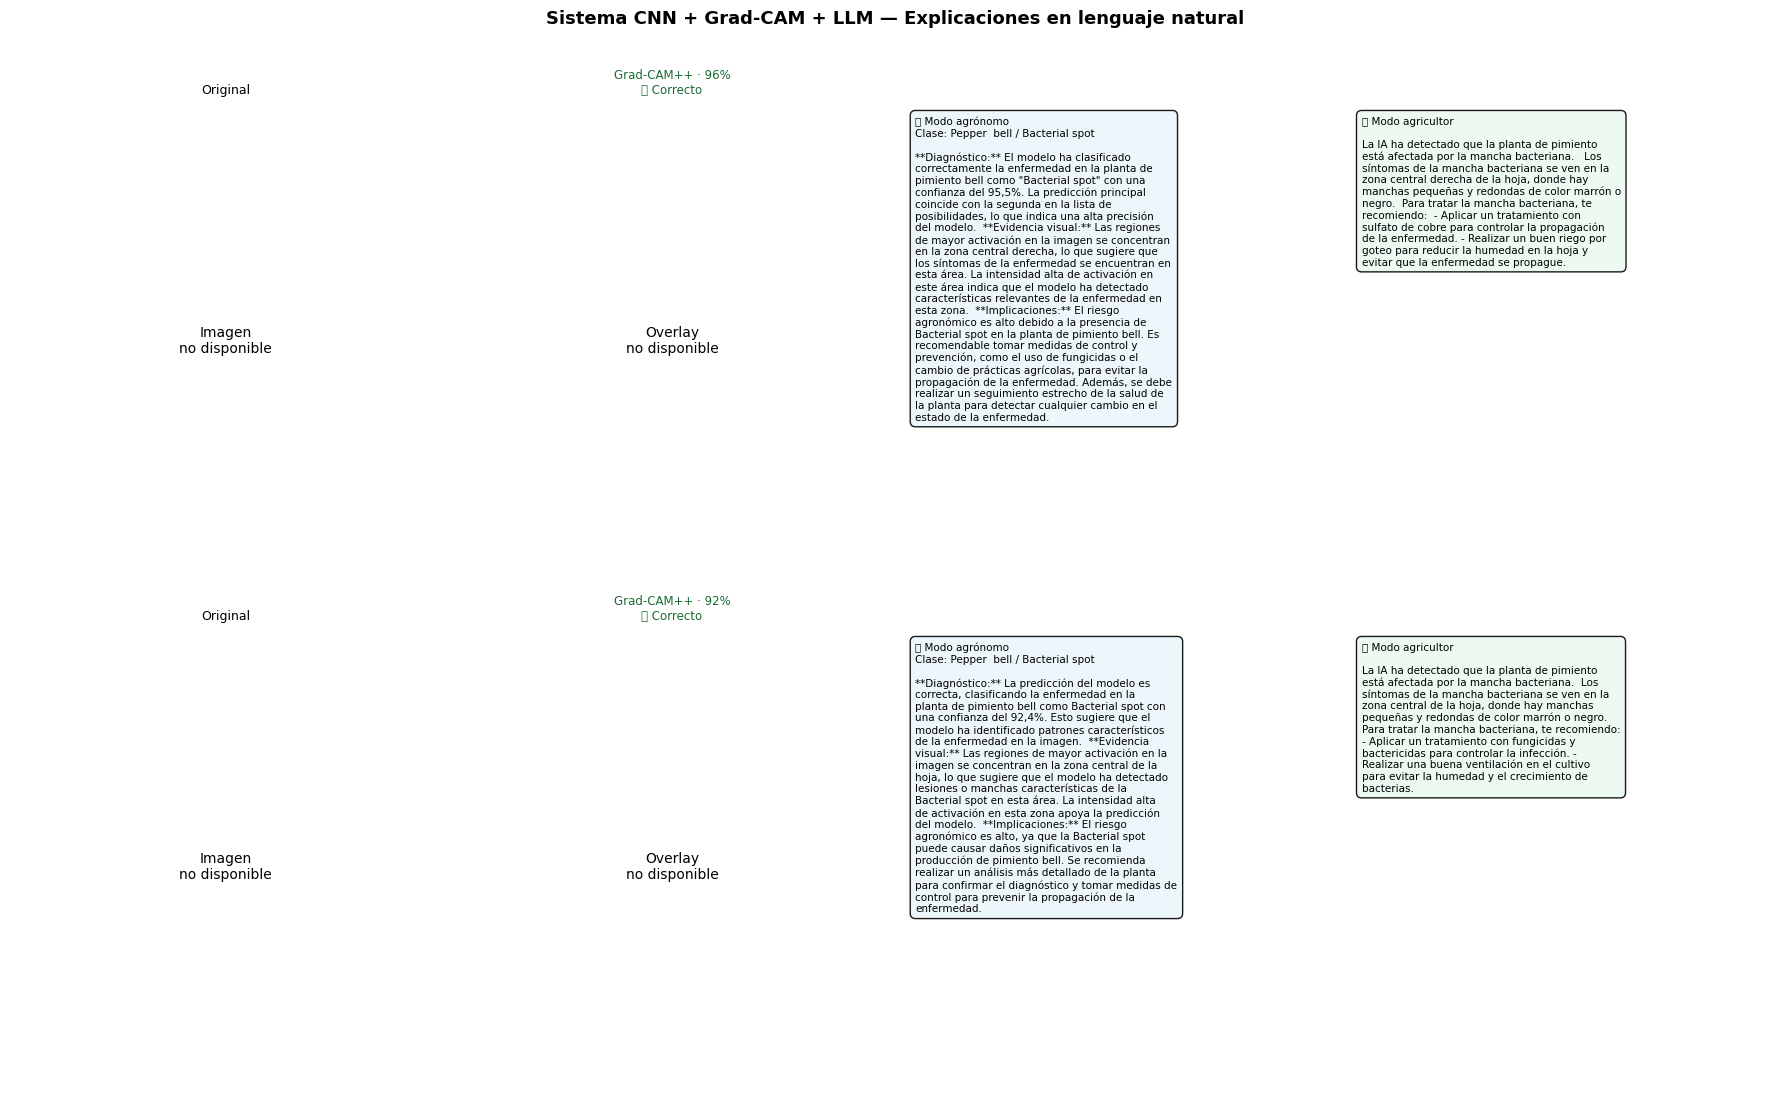

✅ fig11_llm_explanations.png guardada


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image as PILImage
import textwrap, random

random.seed(42)

# Seleccionar ejemplos interesantes: 2 correctos + 1 incorrecto
correctos   = [r for r in enriched_results if r['correct']]
incorrectos = [r for r in enriched_results if not r['correct']]

muestra = random.sample(correctos,   min(2, len(correctos))) + \
          random.sample(incorrectos, min(1, len(incorrectos)))

if not muestra:
    muestra = enriched_results[:3]

N_EJ = len(muestra)
fig  = plt.figure(figsize=(18, N_EJ * 5.5))
fig.suptitle(
    'Sistema CNN + Grad-CAM + LLM — Explicaciones en lenguaje natural',
    fontsize=13, fontweight='bold', y=1.01
)

for row, res in enumerate(muestra):
    # ── Imagen original ──────────────────────────────────────────────────────
    ax_orig = fig.add_subplot(N_EJ, 4, row * 4 + 1)
    try:
        img = PILImage.open(res['image_path']).convert('RGB').resize((224, 224))
        ax_orig.imshow(img)
    except Exception:
        ax_orig.text(0.5, 0.5, 'Imagen\nno disponible', ha='center', va='center')
    ax_orig.set_title('Original', fontsize=9)
    ax_orig.axis('off')

    # ── Grad-CAM overlay ─────────────────────────────────────────────────────
    ax_cam = fig.add_subplot(N_EJ, 4, row * 4 + 2)
    try:
        overlay = PILImage.open(res['overlay_path']).convert('RGB')
        ax_cam.imshow(overlay)
    except Exception:
        ax_cam.text(0.5, 0.5, 'Overlay\nno disponible', ha='center', va='center')
    correct_color = '#1a6b35' if res['correct'] else '#8b1a1a'
    correct_label = '✅ Correcto' if res['correct'] else '❌ Incorrecto'
    ax_cam.set_title(
        f"Grad-CAM++ · {res['confidence']*100:.0f}%\n{correct_label}",
        fontsize=8.5, color=correct_color
    )
    ax_cam.axis('off')

    # ── Explicación agrónomo ──────────────────────────────────────────────────
    ax_agr = fig.add_subplot(N_EJ, 4, row * 4 + 3)
    ax_agr.axis('off')
    texto_agr = textwrap.fill(res.get('llm_agronomo', ''), width=48)
    ax_agr.text(
        0.03, 0.97,
        f"🔬 Modo agrónomo\nClase: {res['pred_label']}\n\n{texto_agr}",
        transform=ax_agr.transAxes, fontsize=7.5, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', alpha=0.9),
        wrap=True
    )

    # ── Explicación agricultor ────────────────────────────────────────────────
    ax_agr2 = fig.add_subplot(N_EJ, 4, row * 4 + 4)
    ax_agr2.axis('off')
    texto_agr2 = textwrap.fill(res.get('llm_agricultor', ''), width=48)
    ax_agr2.text(
        0.03, 0.97,
        f"🌱 Modo agricultor\n\n{texto_agr2}",
        transform=ax_agr2.transAxes, fontsize=7.5, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAFAF1', alpha=0.9),
        wrap=True
    )

plt.tight_layout()
plt.savefig('/content/fig11_llm_explanations.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ fig11_llm_explanations.png guardada')

## 7. Evaluación cualitativa de las explicaciones

Tabla de evaluación manual: ¿son coherentes las explicaciones con las activaciones Grad-CAM?
Se usan 4 criterios simples (sin métrica automática, como corresponde a una evaluación
cualitativa de LLM para el informe).

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Mostrar tabla comparativa de los 10 primeros resultados
filas = []
for r in enriched_results[:10]:
    n_palabras = len(r.get('llm_agronomo', '').split())
    menciona_zona = any(
        word in r.get('llm_agronomo', '').lower()
        for word in ['zona', 'región', 'área', 'manchas', 'parte', 'centro', 'borde',
                     'superior', 'inferior', 'hoja', 'síntoma']
    )
    menciona_enfermedad = r['pred_label'].split('/')[-1].strip().lower().split()[0] in \
                          r.get('llm_agronomo', '').lower()
    filas.append({
        'Clase real'           : r['true_label'][:28],
        'Predicción'           : r['pred_label'][:28],
        'Conf.'                : f"{r['confidence']*100:.0f}%",
        'Correcto'             : '✅' if r['correct'] else '❌',
        'Palabras (agrónomo)'  : n_palabras,
        'Menciona zona CAM'    : '✅' if menciona_zona       else '—',
        'Menciona enfermedad'  : '✅' if menciona_enfermedad else '—',
    })

df_eval = pd.DataFrame(filas)
print('Evaluación cualitativa de explicaciones LLM:')
print(df_eval.to_string(index=False))

# Estadísticas
print()
menciona_zona_pct = df_eval['Menciona zona CAM'].eq('✅').mean() * 100
menciona_enf_pct  = df_eval['Menciona enfermedad'].eq('✅').mean() * 100
words_mean        = df_eval['Palabras (agrónomo)'].mean()
print(f'Coherencia con zona Grad-CAM : {menciona_zona_pct:.0f}% de explicaciones')
print(f'Menciona la enfermedad       : {menciona_enf_pct:.0f}% de explicaciones')
print(f'Longitud media (agrónomo)    : {words_mean:.0f} palabras')

Evaluación cualitativa de explicaciones LLM:
                  Clase real                   Predicción Conf. Correcto  Palabras (agrónomo) Menciona zona CAM Menciona enfermedad
Pepper  bell / Bacterial spo Pepper  bell / Bacterial spo   92%        ✅                  137                 ✅                   ✅
Pepper  bell / Bacterial spo Pepper  bell / Bacterial spo   91%        ✅                  126                 ✅                   ✅
Pepper  bell / Bacterial spo Pepper  bell / Bacterial spo   93%        ✅                  124                 ✅                   —
Pepper  bell / Bacterial spo Pepper  bell / Bacterial spo   96%        ✅                  163                 ✅                   ✅
Pepper  bell / Bacterial spo Pepper  bell / Bacterial spo   92%        ✅                  134                 ✅                   ✅
      Pepper  bell / healthy       Pepper  bell / healthy   95%        ✅                  146                 ✅                   —
      Pepper  bell / healthy   

## 8. Imprimir ejemplos para el informe (Listing del LaTeX)

In [27]:
import json

# Seleccionar el ejemplo más representativo para el Listing del informe
ej = next((r for r in enriched_results if r['correct']), enriched_results[0])

output_informe = {
    'entrada': {
        'imagen'        : ej['image_path'].split('/')[-1],
        'prediccion'    : ej['pred_label'],
        'confianza'     : f"{ej['confidence']*100:.1f}%",
        'zona_gradcam'  : ej['zone_description'],
    },
    'salida_agronomo'  : ej['llm_agronomo'],
    'salida_agricultor': ej['llm_agricultor'],
}

print('──────────────────────────────────────────────────────────')
print('EJEMPLO PARA EL INFORME (Sección 5.3 — Análisis cualitativo)')
print('──────────────────────────────────────────────────────────')
print(json.dumps(output_informe, indent=2, ensure_ascii=False))
print()
print('Copiar el bloque anterior al Listing 1 del LaTeX.')

──────────────────────────────────────────────────────────
EJEMPLO PARA EL INFORME (Sección 5.3 — Análisis cualitativo)
──────────────────────────────────────────────────────────
{
  "entrada": {
    "imagen": "b3cb19d0-df9b-4705-ab26-40aafab8ecca___JR_B.Spot 3206.JPG",
    "prediccion": "Pepper  bell / Bacterial spot",
    "confianza": "92.4%",
    "zona_gradcam": "Las regiones de mayor activación (Grad-CAM++) se concentran en la zona central centro de la imagen, con una intensidad alta. Aproximadamente el 12% del área de la hoja supera el umbral de activación."
  },
  "salida_agronomo": "**Diagnóstico:** La predicción del modelo es correcta, clasificando la enfermedad en la planta de pimiento bell como Bacterial spot con una confianza del 92,4%. Esto sugiere que el modelo ha identificado patrones característicos de la enfermedad en la imagen.\n\n**Evidencia visual:** Las regiones de mayor activación en la imagen se concentran en la zona central de la hoja, lo que sugiere que el model

## 9. Guardar resultados en Google Drive

In [28]:
# ── Guardar JSON con explicaciones LLM ───────────────────────────────────────
out_json = ARTIFACTS / 'llm_results.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(enriched_results, f, indent=2, ensure_ascii=False)

# ── Guardar ejemplo del informe ───────────────────────────────────────────────
out_ejemplo = ARTIFACTS / 'ejemplo_informe.json'
with open(out_ejemplo, 'w', encoding='utf-8') as f:
    json.dump(output_informe, f, indent=2, ensure_ascii=False)

# ── Sincronizar a Drive ───────────────────────────────────────────────────────
print('Sincronizando a Google Drive...')
save_to_drive(out_json,                          subfolder='artifacts')
save_to_drive(out_ejemplo,                       subfolder='artifacts')
save_to_drive('/content/fig11_llm_explanations.png', subfolder='figures')

print()
print('━' * 55)
print('  FASE 4 COMPLETADA ✅')
print('━' * 55)
print(f'  LLM           : LLaMA-3.1-8b-instant (Groq)')
print(f'  Modos         : agrónomo + agricultor')
print(f'  Imágenes proc.: {len(enriched_results)}')
print(f'  Costo total   : $0')
print()
print('  Artefactos en Drive/IA_EAFIT/')
print('    artifacts/llm_results.json       ← resultados completos')
print('    artifacts/ejemplo_informe.json   ← listing para LaTeX')
print('    figures/fig11_llm_explanations.png')
print()
print('  Siguiente paso → Fase 5: FastAPI + informe LaTeX')

Sincronizando a Google Drive...
  ✅ llm_results.json                         → Drive/artifacts/ (50.7 KB)
  ✅ ejemplo_informe.json                     → Drive/artifacts/ (1.8 KB)
  ✅ fig11_llm_explanations.png               → Drive/figures/ (350.5 KB)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FASE 4 COMPLETADA ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM           : LLaMA-3.1-8b-instant (Groq)
  Modos         : agrónomo + agricultor
  Imágenes proc.: 20
  Costo total   : $0

  Artefactos en Drive/IA_EAFIT/
    artifacts/llm_results.json       ← resultados completos
    artifacts/ejemplo_informe.json   ← listing para LaTeX
    figures/fig11_llm_explanations.png

  Siguiente paso → Fase 5: FastAPI + informe LaTeX


---
## Notas para el informe

### Sección 3.1 — Componente LLM

| Parámetro | Valor |
|---|---|
| **Modelo base** | LLaMA-3.1-8b-instant vía Groq Cloud API |
| **Estrategia de prompting** | Few-shot implícito + instrucciones de formato |
| **Temperatura** | 0.4 (respuestas consistentes y factuales) |
| **Max tokens** | 300 |
| **Rol del LLM** | Explicabilidad: traducir predicción + Grad-CAM a lenguaje natural |
| **Modos** | Agrónomo (técnico) y Agricultor (simple + recomendaciones) |
| **Input** | Clase predicha + confianza + descripción textual de zona Grad-CAM |
| **Costo** | $0 (tier gratuito Groq: 500k tokens/día) |

### Sección 6.2 — Limitaciones relevantes
- El LLM no ve la imagen directamente — recibe solo la descripción textual del Grad-CAM. Esto es una limitación de explicabilidad indirecta.
- Las explicaciones varían ligeramente entre ejecuciones (temperatura > 0). Para reproducibilidad completa usar `temperature=0`.
- El modelo puede "alucinar" detalles agronómicos si la confianza de la CNN es baja (<50%).

### Listing sugerido para Sección 5.3
Usar el output de la celda 8 (`ejemplo_informe.json`) como Listing 1 del documento LaTeX.
